# NREL_multi_task
## GCNで実装
3D構造を入力とする

## データセット読み込み

In [ ]:
import sys
import copy
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset

from rdkit import Chem
from rdkit import __version__ as rdkit_version
from rdkit.Chem import Draw

import py3Dmol

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_add_pool
import torch_geometric

from tqdm import tqdm

import os
import json
from typing import List, Dict, Any, Tuple, Optional, Callable

# ------------------------------
# Reproducibility
# ------------------------------
SEED = 1234
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ------------------------------
# Device
# ------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------
# Environment info (for reproducibility)
# ------------------------------
print("===== Environment =====")
print(f"Python           : {sys.version.split()[0]}")
print(f"PyTorch          : {torch.__version__}")
print(f"PyTorch Geometric: {torch_geometric.__version__}")
print(f"RDKit            : {rdkit_version}")
if torch.cuda.is_available():
    print(f"CUDA version     : {torch.version.cuda}")
print("========================")
print("device:", device)

===== Environment =====
Python           : 3.9.23
PyTorch          : 2.2.1+cu121
PyTorch Geometric: 2.6.1
RDKit            : 2025.03.5
CUDA version     : 12.1
device: cuda


In [29]:
# ダウンロードしたデータセットを読み込む
dataset_train = pd.read_csv("../data/NREL/mol_train.csv.gz")
dataset_val = pd.read_csv("../data/NREL/mol_valid.csv.gz")
dataset_test = pd.read_csv("../data/NREL/mol_test.csv.gz")

# 全部くっつける
dataset_full = pd.concat([dataset_train, dataset_val, dataset_test], axis=0)

print("Train dataset size:", len(dataset_train))
print("Validation dataset size:", len(dataset_val))
print("Test dataset size:", len(dataset_test))
print("Full dataset size:", len(dataset_full))

Train dataset size: 84576
Validation dataset size: 5000
Test dataset size: 5000
Full dataset size: 94576


In [30]:
print(dataset_full.columns)

Index(['mol', 'ctag', 'basis', 'total_energy', 'optical_lumo', 'gap', 'homo',
       'lumo', 'spectral_overlap', 'delta_homo', 'delta_lumo',
       'delta_optical_lumo', 'homo_extrapolated', 'lumo_extrapolated',
       'gap_extrapolated', 'optical_lumo_extrapolated', 'smile'],
      dtype='object')


In [31]:
# 目的変数を準備
target_cols = ["gap", "homo", "lumo", "spectral_overlap", "homo_extrapolated", "lumo_extrapolated", "gap_extrapolated", "optical_lumo_extrapolated"]

required_cols = ["mol"] + target_cols
df = dataset_full[required_cols].copy()

for col in target_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=target_cols).reset_index(drop=True)

print("Usable rows:", len(df))
display(df.head(2))

Usable rows: 60404


,mol,gap,homo,lumo,spectral_overlap,homo_extrapolated,lumo_extrapolated,gap_extrapolated,optical_lumo_extrapolated
0,blank\n OpenBabel03101820033D\n\n 53 58 0 0 ...,1.7154,-5.383228,-3.146452,821.664953,-5.044718,-3.193800,1.5668,-3.477918
1,blank\n OpenBabel03101820043D\n\n 58 63 0 0 ...,2.3225,-5.074651,-2.340451,1157.278754,-4.995738,-2.606578,2.0551,-2.940638


In [ ]:
# 1行目の mol block を取得
mol_block = df.loc[0, "mol"]

# RDKitで読み込み
mol = Chem.MolFromMolBlock(mol_block, removeHs=False, sanitize=True)

print("mol is None:", mol is None)
if mol is not None:
    print("num atoms:", mol.GetNumAtoms())
    print("num conformers:", mol.GetNumConformers())

mol is None: False
num atoms: 53
num conformers: 1


In [33]:
!pip install py3Dmol


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [34]:
import py3Dmol
from rdkit import Chem

mol_block = df.loc[0, "mol"]
mol = Chem.MolFromMolBlock(mol_block, removeHs=False, sanitize=True)

viewer = py3Dmol.view(width=600, height=500)
viewer.addModel(Chem.MolToMolBlock(mol), "mol")
viewer.setStyle({"stick": {}})
viewer.zoomTo()
viewer.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [35]:
# ============================================================
# Hold-out split: train / val / test（ランダム分割）
# ============================================================

train_df, temp_df = train_test_split(
    df,
    test_size=0.2,          # 全体の 20% を val + test に回す
    random_state=SEED,
    shuffle=True,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,          # temp の半分ずつ -> 各 10%
    random_state=SEED,
    shuffle=True,
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(
    "Hold-out split sizes ->",
    "train:", len(train_df),
    "val:", len(val_df),
    "test:", len(test_df),
)

# ============================================================
# Robust scaling: median = 0, IQR = 1（train のみで fit）
# ============================================================

def fit_robust_scaler(y: pd.Series):
    y = y.astype(float)
    med = float(y.median())
    q1 = float(y.quantile(0.25))
    q3 = float(y.quantile(0.75))
    iqr = q3 - q1
    if iqr == 0:
        iqr = 1.0
    return med, iqr

def transform_robust(y: pd.Series, med: float, iqr: float):
    return (y.astype(float) - med) / iqr

def inverse_robust(y_scaled, med: float, iqr: float):
    return y_scaled * iqr + med


# ---- train のみで fit ----
scalers = {col: fit_robust_scaler(train_df[col]) for col in target_cols}

# ---- 各 split に適用（コピーしてから列追加）----
train_df = train_df.copy()
val_df   = val_df.copy()
test_df  = test_df.copy()

for col in target_cols:
    med, iqr = scalers[col]
    train_df[f"{col}_scaled"] = transform_robust(train_df[col], med, iqr)
    val_df[f"{col}_scaled"]   = transform_robust(val_df[col],   med, iqr)
    test_df[f"{col}_scaled"]  = transform_robust(test_df[col],  med, iqr)

# ---- 確認ログ（ターゲット毎）----
for col in target_cols:
    med, iqr = scalers[col]
    q1 = float(train_df[f"{col}_scaled"].quantile(0.25))
    q3 = float(train_df[f"{col}_scaled"].quantile(0.75))
    print(
        f"[fit on train] {col}: median(raw)={med:.5g}, IQR(raw)={iqr:.5g} | "
        f"median(scaled)={float(train_df[f'{col}_scaled'].median()):.5g}, IQR(scaled)={(q3-q1):.5g}"
    )

Hold-out split sizes -> train: 48323 val: 6040 test: 6041
[fit on train] gap: median(raw)=2.3003, IQR(raw)=0.66705 | median(scaled)=0, IQR(scaled)=1
[fit on train] homo: median(raw)=-5.1013, IQR(raw)=0.53334 | median(scaled)=0, IQR(scaled)=1
[fit on train] lumo: median(raw)=-2.5026, IQR(raw)=0.70124 | median(scaled)=0, IQR(scaled)=1
[fit on train] spectral_overlap: median(raw)=2153.1, IQR(raw)=2504.7 | median(scaled)=0, IQR(scaled)=1
[fit on train] homo_extrapolated: median(raw)=-4.7955, IQR(raw)=0.56654 | median(scaled)=0, IQR(scaled)=1
[fit on train] lumo_extrapolated: median(raw)=-2.8975, IQR(raw)=0.60953 | median(scaled)=0, IQR(scaled)=1
[fit on train] gap_extrapolated: median(raw)=1.607, IQR(raw)=0.5527 | median(scaled)=0, IQR(scaled)=1
[fit on train] optical_lumo_extrapolated: median(raw)=-3.1921, IQR(raw)=0.57988 | median(scaled)=0, IQR(scaled)=1


## mol → PyTorch Geometric Data 変換（Dataset作成）

In [ ]:
# ============================================================
# Features + mol block -> PyG Data 変換
# （以前の MPNN 用の離散特徴量設計を踏襲）
# ============================================================

# ----------------------------
# 原子・結合の離散特徴量設定
# ----------------------------

# 原子番号・次数の上限（クリップ用）
MAX_ATOMIC_NUM = 100
MAX_DEGREE = 5

# 結合タイプ
# 以前の MPNN と同じ定義
BOND_TYPES = {
    Chem.rdchem.BondType.SINGLE: 0,
    Chem.rdchem.BondType.DOUBLE: 1,
    Chem.rdchem.BondType.TRIPLE: 2,
    Chem.rdchem.BondType.AROMATIC: 3,
}
NUM_BOND_TYPES = 4

# ----------------------------
# 追加の原子特徴量
#  - 形式電荷
#  - 混成軌道
# ----------------------------

# 形式電荷（クリップして離散化）
MIN_FC, MAX_FC = -2, 2
FC_OFFSET = -MIN_FC               # -2..2 -> 0..4
NUM_FC = (MAX_FC - MIN_FC + 1)

# 混成軌道タイプ
HYB_MAP = {
    Chem.rdchem.HybridizationType.SP: 0,
    Chem.rdchem.HybridizationType.SP2: 1,
    Chem.rdchem.HybridizationType.SP3: 2,
    Chem.rdchem.HybridizationType.SP3D: 3,
    Chem.rdchem.HybridizationType.SP3D2: 4,
}
HYB_UNKNOWN = 5
NUM_HYB = 6


def atom_features(atom: Chem.rdchem.Atom) -> torch.Tensor:
    """
    原子特徴量（すべて離散値）
    x[:, :] の各列の意味：
      x[:,0]: 原子番号（クリップあり）
      x[:,1]: 原子次数（クリップあり）
      x[:,2]: 芳香族フラグ（0/1）
      x[:,3]: 形式電荷（-2..2 を 0..4 に変換）
      x[:,4]: 混成軌道タイプ

    ※ 以前の MPNN コードと同じ設計
    """
    # 原子番号（上限100でクリップ）
    atomic_num = min(atom.GetAtomicNum(), MAX_ATOMIC_NUM)

    # degree（隣接原子数）を上限5でクリップ
    degree = min(atom.GetDegree(), MAX_DEGREE)

    # 芳香族フラグ
    aromatic = int(atom.GetIsAromatic())

    # 形式電荷を -2..2 にクリップし、0..4 に変換
    formal_charge = atom.GetFormalCharge()
    formal_charge = max(MIN_FC, min(formal_charge, MAX_FC)) + FC_OFFSET

    # 混成軌道（未知は HYB_UNKNOWN）
    hyb_idx = HYB_MAP.get(atom.GetHybridization(), HYB_UNKNOWN)

    return torch.tensor([atomic_num, degree, aromatic, formal_charge, hyb_idx], dtype=torch.long)

def bond_features(bond: Chem.rdchem.Bond) -> torch.Tensor:
    """
    結合特徴量（離散）
    edge_attr[:, :] の各列の意味：
      edge_attr[:,0]: 結合タイプ（SINGLE/DOUBLE/TRIPLE/AROMATIC）
      edge_attr[:,1]: 共役フラグ（0/1）
      edge_attr[:,2]: 環内結合フラグ（0/1）

    ※ 以前の MPNN コードと同じ設計
    """
    # 結合タイプを整数IDに変換
    bond_type = BOND_TYPES.get(bond.GetBondType(), 0)

    # 共役結合かどうか
    conjugated = int(bond.GetIsConjugated())

    # 環内結合かどうか
    in_ring = int(bond.IsInRing())

    return torch.tensor([bond_type, conjugated, in_ring], dtype=torch.long)


def molblock_to_pyg(mol_block: str, y_values: list):
    """
    mol block 文字列から PyG Data を作る関数
    （以前の smiles_to_pyg の mol block 版）

    Parameters
    ----------
    mol_block : str
        mol block 文字列（原子・結合・3D座標を含む）
    y_values : list
        目的変数のリスト

    Returns
    -------
    Data or None
        PyTorch Geometric の Data オブジェクト
    """
    # mol block から RDKit Mol を作成
    # removeHs=False により水素を保持
    mol = Chem.MolFromMolBlock(mol_block, removeHs=False)

    # 読み込み失敗時
    if mol is None:
        return None

    # ----------------------------
    # ノード特徴
    # ----------------------------
    # 各原子について離散特徴ベクトルを作る
    x = torch.stack([atom_features(a) for a in mol.GetAtoms()], dim=0)  # [N, 5]

    # ----------------------------
    # エッジ（無向結合 -> 両方向の有向エッジ）
    # ----------------------------
    edge_index_list = []
    edge_attr_list = []

    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()

        # この結合の離散特徴
        bf = bond_features(bond)

        # i -> j, j -> i の両方向を登録
        edge_index_list += [[i, j], [j, i]]
        edge_attr_list  += [bf, bf]

    # 結合が1本もない場合の保険
    if len(edge_index_list) == 0:
        edge_index = torch.empty((2, 0), dtype=torch.long)
        edge_attr  = torch.empty((0, 3), dtype=torch.long)
    else:
        # PyG形式 [2, E] に変換
        edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()

        # edge_attr は [E, 3]
        edge_attr = torch.stack(edge_attr_list, dim=0)

    # ----------------------------
    # 目的変数
    # ----------------------------
    y = torch.tensor(y_values, dtype=torch.float).view(1, -1)  # [1, T]

    # ----------------------------
    # PyG Data にまとめる
    # ----------------------------
    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

    # 元データ確認用に mol_block も保持しておく（任意）
    data.mol_block = mol_block

    return data


class MolBlockGraphDataset(Dataset):
    """
    DataFrame（mol block + 目的変数）から
    PyG Data のリストを作る Dataset

    以前の SmilesGraphDataset の mol block 版
    """
    def __init__(
        self,
        df,
        mol_col: str,
        target_cols: list,
        use_scaled: bool = True,
    ):
        self.data_list = []
        bad = 0

        # 学習に使う目的変数列を選ぶ
        # use_scaled=True なら *_scaled を使う
        y_cols = [f"{c}_scaled" for c in target_cols] if use_scaled else target_cols

        # 必須列チェック
        needed = [mol_col] + y_cols
        missing = [c for c in needed if c not in df.columns]
        if missing:
            raise ValueError(f"df に必要列がありません: {missing}. columns={list(df.columns)}")

        # DataFrame の各行を順に PyG Data に変換
        for _, row in df.iterrows():
            mol_block = row[mol_col]
            y_vals = [row[c] for c in y_cols]

            d = molblock_to_pyg(mol_block, y_vals)

            if d is None:
                bad += 1
            else:
                self.data_list.append(d)

        print(f"Converted graphs: {len(self.data_list)} / {len(df)} (invalid mol blocks removed: {bad})")

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        return self.data_list[idx]

In [37]:
# --- Build datasets ---
train_dataset = MolBlockGraphDataset(train_df, mol_col="mol", target_cols=target_cols, use_scaled=True)
val_dataset   = MolBlockGraphDataset(val_df,   mol_col="mol", target_cols=target_cols, use_scaled=True)
test_dataset  = MolBlockGraphDataset(test_df,  mol_col="mol", target_cols=target_cols, use_scaled=True)

# quick check
d0 = train_dataset[0]
print(d0)
print("x shape:", d0.x.shape)
print("edge_index shape:", d0.edge_index.shape)
print("edge_attr shape:", d0.edge_attr.shape)
print("y shape:", d0.y.shape)
print("y:", d0.y)

[20:19:32] Explicit valence for atom # 64 C, 5, is greater than permitted
[20:19:37] Explicit valence for atom # 46 C, 5, is greater than permitted
[20:19:41] Explicit valence for atom # 63 C, 5, is greater than permitted
[20:19:43] Explicit valence for atom # 46 C, 5, is greater than permitted
[20:19:45] Explicit valence for atom # 46 C, 5, is greater than permitted
[20:19:52] Explicit valence for atom # 39 C, 5, is greater than permitted
[20:19:54] Explicit valence for atom # 30 C, 5, is greater than permitted
[20:19:55] Explicit valence for atom # 20 C, 5, is greater than permitted
[20:19:57] Explicit valence for atom # 52 C, 5, is greater than permitted
[20:20:01] Explicit valence for atom # 52 C, 5, is greater than permitted
[20:20:05] Explicit valence for atom # 52 C, 5, is greater than permitted
[20:20:30] Explicit valence for atom # 37 N, 4, is greater than permitted
[20:20:38] Explicit valence for atom # 46 C, 5, is greater than permitted
[20:20:51] Explicit valence for atom #

Converted graphs: 48307 / 48323 (invalid mol blocks removed: 16)


[20:21:36] Explicit valence for atom # 46 C, 5, is greater than permitted
[20:21:39] Explicit valence for atom # 35 C, 5, is greater than permitted


Converted graphs: 6038 / 6040 (invalid mol blocks removed: 2)
Converted graphs: 6041 / 6041 (invalid mol blocks removed: 0)
Data(x=[52, 5], edge_index=[2, 112], edge_attr=[112, 3], y=[1, 8], mol_block='blank
 OpenBabel03101820463D

 52 56  0  0  0  0  0  0  0  0999 V2000
    7.7496    0.5984    0.3231 C   0  0  0  0  0  0  0  0  0  0  0  0
    7.1417   -0.6184    0.1394 C   0  0  0  0  0  0  0  0  0  0  0  0
    5.7219   -0.5286    0.0546 C   0  0  0  0  0  0  0  0  0  0  0  0
    5.2595    0.7674    0.1777 C   0  0  0  0  0  0  0  0  0  0  0  0
    6.5941    1.8811    0.3991 S   0  0  0  0  0  0  0  0  0  0  0  0
    8.8084    0.7926    0.4137 H   0  0  0  0  0  0  0  0  0  0  0  0
    5.0626   -1.3759   -0.0909 H   0  0  0  0  0  0  0  0  0  0  0  0
    7.2067   -2.9667   -0.1822 C   0  0  0  0  0  0  0  0  0  0  0  0
    6.5020   -3.2060    0.6246 H   0  0  0  0  0  0  0  0  0  0  0  0
    6.6658   -2.9479   -1.1372 H   0  0  0  0  0  0  0  0  0  0  0  0
    8.2414   -4.0772   -0.24

- 原子数52, 有向エッジ数112, 目的変数8個
- 112本なのは、i -> j, j -> iの両方向で入れているから　⇒　つまり結合の数は56本

## PyG DataLoaderの作成

In [38]:
# DataLoader + sanity check

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

# 1バッチ取り出して形確認
batch = next(iter(train_loader))
print(batch)

print("batch.x:", batch.x.shape)               # [total_nodes_in_batch, 5]
print("batch.edge_index:", batch.edge_index.shape)
print("batch.edge_attr:", batch.edge_attr.shape)
print("batch.y:", batch.y.shape)               # [num_graphs_in_batch, num_tasks]
print("batch.batch:", batch.batch.shape)       # [total_nodes_in_batch]
print("num_graphs:", batch.num_graphs)

# 明示的に期待shapeを出す（混乱防止）
num_tasks = batch.y.size(-1) if batch.y.ndim == 2 else 1
print("inferred num_tasks:", num_tasks)

# GPUに乗せてみる（エラー出ないか確認）
batch = batch.to(device)
print("moved to device OK")

DataBatch(x=[1947, 5], edge_index=[2, 4328], edge_attr=[4328, 3], y=[32, 8], mol_block=[32], batch=[1947], ptr=[33])
batch.x: torch.Size([1947, 5])
batch.edge_index: torch.Size([2, 4328])
batch.edge_attr: torch.Size([4328, 3])
batch.y: torch.Size([32, 8])
batch.batch: torch.Size([1947])
num_graphs: 32
inferred num_tasks: 8
moved to device OK


- 32分子を1バッチにまとめた
- その中の原子数が1947
- 全有向エッジ数が4328
- 各分子に8個のターゲット
- batchベクトルが各原子の所属分子IDを持っている

## GCNRegressorを定義

In [ ]:
class GCNRegressor(nn.Module):
    """
    以前の MPNN と同じ原子特徴埋め込みを使う GCN 回帰モデル
    - ノード特徴: 離散特徴 5種
    - GCNConv: edge_index のみ使用
    - Readout: global_add_pool
    - Head: MPNNに近い MLP
    """
    def __init__(
        self,
        hidden_dim: int = 128,
        num_layers: int = 3,
        num_targets: int = 8,
        dropout: float = 0.0,
    ):
        super().__init__()

        # ----------------------------
        # 1) 離散ノード特徴の埋め込み
        # ----------------------------
        self.emb_atomic = nn.Embedding(MAX_ATOMIC_NUM + 1, 64)
        self.emb_degree = nn.Embedding(MAX_DEGREE + 1, 16)
        self.emb_aroma  = nn.Embedding(2, 8)
        self.emb_fc     = nn.Embedding(NUM_FC, 8)
        self.emb_hyb    = nn.Embedding(NUM_HYB, 8)

        # 64 + 16 + 8 + 8 + 8 = 104
        node_in_dim = 64 + 16 + 8 + 8 + 8
        self.node_proj = nn.Linear(node_in_dim, hidden_dim)

        # ----------------------------
        # 2) GCN layers
        # ----------------------------
        self.convs = nn.ModuleList()
        for _ in range(num_layers):
            self.convs.append(GCNConv(hidden_dim, hidden_dim))

        # ----------------------------
        # 3) Readout後の MLP head
        # ----------------------------
        self.fc1 = nn.Linear(hidden_dim, 512)
        self.bn1 = nn.BatchNorm1d(512)

        self.fc2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)

        self.out = nn.Linear(256, num_targets)

        self.dropout = dropout

    def forward(self, data):
        """
        data.x         : [N, 5] long
        data.edge_index: [2, E]
        data.batch     : [N]
        """
        x = data.x
        edge_index = data.edge_index
        batch = data.batch

        # ----------------------------
        # 離散特徴を取り出す
        # ----------------------------
        atomic_num    = x[:, 0].clamp(0, MAX_ATOMIC_NUM)
        degree        = x[:, 1].clamp(0, MAX_DEGREE)
        aromatic      = x[:, 2].clamp(0, 1)
        formal_charge = x[:, 3].clamp(0, NUM_FC - 1)
        hybridization = x[:, 4].clamp(0, NUM_HYB - 1)

        # long 型にそろえる
        atomic_num    = atomic_num.long()
        degree        = degree.long()
        aromatic      = aromatic.long()
        formal_charge = formal_charge.long()
        hybridization = hybridization.long()

        # ----------------------------
        # Embeddingして連結
        # ----------------------------
        h = torch.cat([
            self.emb_atomic(atomic_num),
            self.emb_degree(degree),
            self.emb_aroma(aromatic),
            self.emb_fc(formal_charge),
            self.emb_hyb(hybridization),
        ], dim=-1)  # [N, 104]

        # hidden_dim へ射影
        h = self.node_proj(h)  # [N, hidden_dim]

        # ----------------------------
        # GCN message passing
        # ----------------------------
        for conv in self.convs:
            h = conv(h, edge_index)
            h = F.relu(h)
            if self.dropout > 0:
                h = F.dropout(h, p=self.dropout, training=self.training)

        # ----------------------------
        # Graph-level pooling
        # ----------------------------
        g = global_add_pool(h, batch)  # [B, hidden_dim]

        # ----------------------------
        # MLP head
        # ----------------------------
        z = self.bn1(self.fc1(g))
        z = F.relu(z)
        if self.dropout > 0:
            z = F.dropout(z, p=self.dropout, training=self.training)

        z = self.bn2(self.fc2(z))
        z = F.relu(z)
        if self.dropout > 0:
            z = F.dropout(z, p=self.dropout, training=self.training)

        out = self.out(z)  # [B, num_targets]
        return out

In [42]:
# 動作確認
num_targets = len(target_cols)

model = GCNRegressor(
    hidden_dim=128,
    num_layers=3,
    num_targets=num_targets,
    dropout=0.0,
).to(device)

with torch.no_grad():
    pred = model(batch)

print("pred shape:", pred.shape)
print(pred[:2])

pred shape: torch.Size([32, 8])
tensor([[ 0.3583,  0.6780, -0.2057,  0.1903,  0.3510, -0.5010, -0.2528, -0.1420],
        [-0.0102, -0.0993,  0.0801,  0.3716, -0.0054, -0.1681,  0.0166, -0.2728]],
       device='cuda:0')


## 学習

In [43]:
# ============================================================
# 損失関数・最適化・学習率スケジューラ
# ============================================================

# マルチタスク回帰なので、全タスク平均の MSE
criterion = nn.MSELoss()

# Adam optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=0.0
)

# 元コード踏襲のごく弱い減衰
decay = 2e-6
scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=lambda epoch: (1.0 - decay) ** epoch
)


# ============================================================
# 学習関数
# ============================================================

def train_one_epoch(model, loader, optimizer, criterion, device):
    """
    1エポック分の学習

    Returns
    -------
    train_mse : float
        分子あたり平均 MSE（scaled 空間）
    train_mae : float
        分子あたり平均 MAE（scaled 空間）
    """
    model.train()
    total_loss = 0.0
    total_mae = 0.0
    n = 0

    for batch in tqdm(loader, desc="train", leave=False):
        batch = batch.to(device)

        optimizer.zero_grad()

        # 予測
        pred = model(batch)      # [B, T]
        y = batch.y.float()      # [B, T]

        # 損失
        loss = criterion(pred, y)

        # 更新
        loss.backward()
        optimizer.step()

        # 参考指標
        with torch.no_grad():
            mae = torch.mean(torch.abs(pred - y))

        bsz = batch.num_graphs
        total_loss += loss.item() * bsz
        total_mae  += mae.item() * bsz
        n += bsz

    return total_loss / n, total_mae / n


@torch.no_grad()
def evaluate_scaled(model, loader, device, target_cols):
    """
    scaled 空間での評価

    Returns
    -------
    results : dict
        {
          target_name: {"mae":..., "rmse":..., "r2":...},
          "_macro": {...}
        }
    """
    model.eval()
    preds, ys = [], []

    for batch in tqdm(loader, desc="eval_scaled", leave=False):
        batch = batch.to(device)
        pred = model(batch).cpu()
        y = batch.y.cpu()
        preds.append(pred)
        ys.append(y)

    preds = torch.cat(preds, dim=0)   # [N, T]
    ys    = torch.cat(ys, dim=0)      # [N, T]

    results = {}
    for i, col in enumerate(target_cols):
        resid = preds[:, i] - ys[:, i]

        mae = resid.abs().mean().item()
        rmse = torch.sqrt((resid ** 2).mean()).item()

        y_mean = ys[:, i].mean()
        ss_tot = torch.sum((ys[:, i] - y_mean) ** 2)
        ss_res = torch.sum(resid ** 2)
        r2 = (1.0 - ss_res / (ss_tot + 1e-12)).item()

        results[col] = {"mae": mae, "rmse": rmse, "r2": r2}

    results["_macro"] = {
        "mae": float(np.mean([results[c]["mae"] for c in target_cols])),
        "rmse": float(np.mean([results[c]["rmse"] for c in target_cols])),
        "r2": float(np.mean([results[c]["r2"] for c in target_cols])),
    }

    return results


@torch.no_grad()
def evaluate_raw(model, loader, device, target_cols, scalers):
    """
    raw 空間（robust scaling を逆変換）での評価
    """
    model.eval()
    preds, ys = [], []

    for batch in tqdm(loader, desc="eval_raw", leave=False):
        batch = batch.to(device)
        pred = model(batch).cpu()   # scaled
        y = batch.y.cpu()           # scaled
        preds.append(pred)
        ys.append(y)

    preds = torch.cat(preds, dim=0)
    ys    = torch.cat(ys, dim=0)

    results = {}
    for i, col in enumerate(target_cols):
        med, iqr = scalers[col]

        pred_raw = preds[:, i] * iqr + med
        y_raw    = ys[:, i] * iqr + med

        resid = pred_raw - y_raw
        mae = resid.abs().mean().item()
        rmse = torch.sqrt((resid ** 2).mean()).item()

        y_mean = y_raw.mean()
        ss_tot = torch.sum((y_raw - y_mean) ** 2)
        ss_res = torch.sum(resid ** 2)
        r2 = (1.0 - ss_res / (ss_tot + 1e-12)).item()

        results[col] = {"mae": mae, "rmse": rmse, "r2": r2}

    results["_macro"] = {
        "mae": float(np.mean([results[c]["mae"] for c in target_cols])),
        "rmse": float(np.mean([results[c]["rmse"] for c in target_cols])),
        "r2": float(np.mean([results[c]["r2"] for c in target_cols])),
    }

    return results


def results_to_df(results: dict, title: str):
    """
    評価結果を DataFrame にまとめる
    """
    dfm = pd.DataFrame(results).T
    dfm.index.name = "target"
    dfm = dfm[["mae", "rmse", "r2"]]
    print(f"\n[{title}]")
    print(dfm)
    return dfm

In [44]:
# ============================================================
# 学習ループ
# ============================================================

max_epochs = 500
patience = 20

# 全体平均で early stopping
monitor_col = "_macro"
monitor_key = "rmse"   # "rmse" or "mae"

best_metric = float("inf")
best_state = None
bad_epochs = 0

history = []

# ログ表示用
show_cols = target_cols[:3] if len(target_cols) >= 3 else target_cols

for epoch in range(1, max_epochs + 1):

    # ----------------------------
    # 1) Train
    # ----------------------------
    train_mse, train_mae = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )

    # ----------------------------
    # 2) Validation (scaled)
    # ----------------------------
    val_scaled = evaluate_scaled(
        model, val_loader, device, target_cols
    )

    if monitor_col not in val_scaled:
        raise KeyError(
            f"monitor_col='{monitor_col}' が val_scaled にありません: keys={list(val_scaled.keys())}"
        )

    current = val_scaled[monitor_col][monitor_key]

    # ----------------------------
    # 3) Scheduler step
    # ----------------------------
    scheduler.step()
    lr = optimizer.param_groups[0]["lr"]

    # ----------------------------
    # 4) Log 出力
    # ----------------------------
    macro = val_scaled["_macro"]
    parts = [
        f"[Epoch {epoch:03d}] lr={lr:.2e}",
        f"train_MSE={train_mse:.4f} train_MAE={train_mae:.4f}",
        f"VAL_macro_RMSE={macro['rmse']:.4f} macro_MAE={macro['mae']:.4f} macro_R2={macro['r2']:.4f}",
    ]
    for c in show_cols:
        r = val_scaled[c]
        parts.append(
            f"VAL {c}_RMSE={r['rmse']:.4f} {c}_MAE={r['mae']:.4f} {c}_R2={r['r2']:.4f}"
        )
    print(" | ".join(parts))

    # ----------------------------
    # 5) history 保存
    # ----------------------------
    row = {
        "epoch": epoch,
        "lr": lr,
        "train_mse": train_mse,
        "train_mae": train_mae,
        f"val_{monitor_col}_{monitor_key}": current,
        "val_macro_rmse": macro["rmse"],
        "val_macro_mae": macro["mae"],
        "val_macro_r2": macro["r2"],
    }
    for c in target_cols:
        row[f"val_{c}_rmse"] = val_scaled[c]["rmse"]
        row[f"val_{c}_mae"] = val_scaled[c]["mae"]
        row[f"val_{c}_r2"] = val_scaled[c]["r2"]
    history.append(row)

    # ----------------------------
    # 6) Early stopping
    # ----------------------------
    if current < best_metric - 1e-6:
        best_metric = current
        best_state = copy.deepcopy(model.state_dict())
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print(
                f"Early stopping triggered (patience={patience}). "
                f"Best VAL {monitor_col}_{monitor_key}={best_metric:.4f}"
            )
            break


# ============================================================
# 最良モデル復元
# ============================================================

if best_state is not None:
    model.load_state_dict(best_state)

model.to(device).eval()

# 復元後に Validation を再評価
val_scaled_best = evaluate_scaled(model, val_loader, device, target_cols)

print("\n===== BEST MODEL: VAL (scaled) =====")
print(
    f"monitor: {monitor_col}_{monitor_key} = "
    f"{val_scaled_best[monitor_col][monitor_key]:.4f}"
)


# ============================================================
# TEST 評価
# ============================================================

test_scaled = evaluate_scaled(model, test_loader, device, target_cols)
test_raw    = evaluate_raw(model, test_loader, device, target_cols, scalers)

print("\n===== FINAL TEST (scaled space) =====")
for k in (["_macro"] + show_cols):
    print(k, test_scaled[k])

print("\n===== FINAL TEST (raw space) =====")
for k in (["_macro"] + show_cols):
    print(k, test_raw[k])

test_scaled_df = results_to_df(test_scaled, "TEST scaled metrics")
test_raw_df    = results_to_df(test_raw,    "TEST raw metrics")

history_df = pd.DataFrame(history)
display(history_df.head())

[Epoch 001] lr=1.00e-03 | train_MSE=0.1609 train_MAE=0.3003 | VAL_macro_RMSE=0.3701 macro_MAE=0.2867 macro_R2=0.7774 | VAL gap_RMSE=0.3298 gap_MAE=0.2548 gap_R2=0.8189 | VAL homo_RMSE=0.2833 homo_MAE=0.2107 homo_R2=0.8742 | VAL lumo_RMSE=0.2854 lumo_MAE=0.2220 lumo_R2=0.8701


[Epoch 002] lr=1.00e-03 | train_MSE=0.0974 train_MAE=0.2339 | VAL_macro_RMSE=0.2968 macro_MAE=0.2276 macro_R2=0.8598 | VAL gap_RMSE=0.3389 gap_MAE=0.2672 gap_R2=0.8087 | VAL homo_RMSE=0.2676 homo_MAE=0.2022 homo_R2=0.8877 | VAL lumo_RMSE=0.2672 lumo_MAE=0.2079 lumo_R2=0.8861


[Epoch 003] lr=1.00e-03 | train_MSE=0.0797 train_MAE=0.2117 | VAL_macro_RMSE=0.2607 macro_MAE=0.1941 macro_R2=0.8902 | VAL gap_RMSE=0.2774 gap_MAE=0.2097 gap_R2=0.8719 | VAL homo_RMSE=0.2120 homo_MAE=0.1610 homo_R2=0.9296 | VAL lumo_RMSE=0.2435 lumo_MAE=0.1863 lumo_R2=0.9054


[Epoch 004] lr=1.00e-03 | train_MSE=0.0693 train_MAE=0.1969 | VAL_macro_RMSE=0.2363 macro_MAE=0.1789 macro_R2=0.9104 | VAL gap_RMSE=0.2324 gap_MAE=0.1802 gap_R2=0.9100 | VAL homo_RMSE=0.2607 homo_MAE=0.2086 homo_R2=0.8935 | VAL lumo_RMSE=0.1744 lumo_MAE=0.1321 lumo_R2=0.9515


[Epoch 005] lr=1.00e-03 | train_MSE=0.0634 train_MAE=0.1883 | VAL_macro_RMSE=0.2079 macro_MAE=0.1577 macro_R2=0.9284 | VAL gap_RMSE=0.1909 gap_MAE=0.1431 gap_R2=0.9393 | VAL homo_RMSE=0.1845 homo_MAE=0.1389 homo_R2=0.9467 | VAL lumo_RMSE=0.1453 lumo_MAE=0.1113 lumo_R2=0.9663


...

[Epoch 162] lr=1.00e-03 | train_MSE=0.0137 train_MAE=0.0860 | VAL_macro_RMSE=0.1173 macro_MAE=0.0800 macro_R2=0.9770 | VAL gap_RMSE=0.0869 gap_MAE=0.0637 gap_R2=0.9874 | VAL homo_RMSE=0.0928 homo_MAE=0.0679 homo_R2=0.9865 | VAL lumo_RMSE=0.0754 lumo_MAE=0.0583 lumo_R2=0.9909


[Epoch 163] lr=1.00e-03 | train_MSE=0.0137 train_MAE=0.0859 | VAL_macro_RMSE=0.1161 macro_MAE=0.0790 macro_R2=0.9777 | VAL gap_RMSE=0.0877 gap_MAE=0.0647 gap_R2=0.9872 | VAL homo_RMSE=0.0935 homo_MAE=0.0683 homo_R2=0.9863 | VAL lumo_RMSE=0.0736 lumo_MAE=0.0554 lumo_R2=0.9914
Early stopping triggered (patience=20). Best VAL _macro_rmse=0.1147



===== BEST MODEL: VAL (scaled) =====
monitor: _macro_rmse = 0.1147



===== FINAL TEST (scaled space) =====
_macro {'mae': 0.07956454949453473, 'rmse': 0.11583023518323898, 'r2': 0.9783479571342468}
gap {'mae': 0.06867946684360504, 'rmse': 0.0942547619342804, 'r2': 0.9854414463043213}
homo {'mae': 0.06883778423070908, 'rmse': 0.0997595489025116, 'r2': 0.9852719306945801}
lumo {'mae': 0.053743209689855576, 'rmse': 0.07312243431806564, 'r2': 0.9918978810310364}

===== FINAL TEST (raw space) =====
_macro {'mae': 21.41659066081047, 'rmse': 31.7748916298151, 'r2': 0.9783479571342468}
gap {'mae': 0.04581263288855553, 'rmse': 0.06287263333797455, 'r2': 0.9854414463043213}
homo {'mae': 0.036714162677526474, 'rmse': 0.053206074982881546, 'r2': 0.9852719306945801}
lumo {'mae': 0.03768673911690712, 'rmse': 0.051276180893182755, 'r2': 0.9918978810310364}

[TEST scaled metrics]
                                mae      rmse        r2
target                                                 
gap                        0.068679  0.094255  0.985441
homo                   

,epoch,lr,train_mse,train_mae,val__macro_rmse,val_macro_rmse,val_macro_mae,val_macro_r2,val_gap_rmse,val_gap_mae,...,val_homo_extrapolated_r2,val_lumo_extrapolated_rmse,val_lumo_extrapolated_mae,val_lumo_extrapolated_r2,val_gap_extrapolated_rmse,val_gap_extrapolated_mae,val_gap_extrapolated_r2,val_optical_lumo_extrapolated_rmse,val_optical_lumo_extrapolated_mae,val_optical_lumo_extrapolated_r2
0,1,0.001,0.160889,0.300297,0.370050,0.370050,0.286651,0.777365,0.329755,0.254774,...,0.831018,0.382915,0.294454,0.786689,0.478484,0.351880,0.615043,0.358023,0.276896,0.814285
1,2,0.001,0.097439,0.233923,0.296760,0.296760,0.227641,0.859839,0.338913,0.267241,...,0.861643,0.263979,0.195485,0.898622,0.364068,0.271848,0.777135,0.257588,0.193311,0.903866
2,3,0.001,0.079745,0.211725,0.260718,0.260718,0.194101,0.890217,0.277358,0.209704,...,0.913149,0.296554,0.220714,0.872057,0.349001,0.247549,0.795200,0.281686,0.212265,0.885038
3,4,0.001,0.069328,0.196884,0.236317,0.236317,0.178884,0.910365,0.232433,0.180166,...,0.881641,0.231979,0.167323,0.921710,0.300854,0.223178,0.847810,0.227635,0.168582,0.924924
4,5,0.001,0.063372,0.188273,0.207929,0.207929,0.157684,0.928422,0.190940,0.143129,...,0.921361,0.219025,0.164542,0.930210,0.319936,0.250028,0.827891,0.214292,0.166464,0.933467


In [45]:
# 可視化用ユーティリティ関数
@torch.no_grad()
def predict_on_loader(model, loader, device, desc=None):
    """
    Returns:
      pred:  [N_graphs, T]
      true:  [N_graphs, T]
      smiles: list[str] length N_graphs
    """
    model.eval()
    all_pred = []
    all_true = []
    all_smiles = []

    it = loader
    if desc is not None:
        it = tqdm(loader, desc=desc, leave=False)

    for batch in it:
        batch = batch.to(device)

        pred = model(batch)              # [B, T]
        y = batch.y.float()              # [B, T]

        all_pred.append(pred.detach().cpu())
        all_true.append(y.detach().cpu())

        # batch.smiles は DataLoader によって list になっている想定
        if hasattr(batch, "smiles"):
            all_smiles.extend(list(batch.smiles))
        else:
            all_smiles.extend([""] * int(batch.num_graphs))

    pred = torch.cat(all_pred, dim=0)    # [N, T]
    true = torch.cat(all_true, dim=0)    # [N, T]

    # 整合チェック
    n = true.shape[0]
    if len(all_smiles) != n:
        all_smiles = all_smiles[:n]

    return pred, true, all_smiles

In [46]:
@torch.no_grad()
def regression_metrics_torch(y_true: torch.Tensor, y_pred: torch.Tensor):
    """
    1つのターゲットに対して回帰指標（MAE / RMSE / R^2）を計算する。

    Parameters
    ----------
    y_true : torch.Tensor, shape [N]
        正解値（CPUテンソル想定。GPUでも動くが最後に .item() するためCPU推奨）
    y_pred : torch.Tensor, shape [N]
        予測値

    Returns
    -------
    mae : float
    rmse: float
    r2  : float
    """
    # 念のため float 化（学習で float を使っていても型が混ざることがあるため）
    y_true = y_true.float()
    y_pred = y_pred.float()

    resid = y_pred - y_true

    # 平均絶対誤差（MAE）
    mae = resid.abs().mean().item()

    # 二乗平均平方根誤差（RMSE）
    rmse = torch.sqrt((resid ** 2).mean()).item()

    # 決定係数（R^2）
    # R^2 = 1 - SS_res / SS_tot
    y_mean = y_true.mean()
    ss_tot = torch.sum((y_true - y_mean) ** 2)
    ss_res = torch.sum(resid ** 2)
    r2 = (1.0 - ss_res / (ss_tot + 1e-12)).item()

    return mae, rmse, r2

def inverse_robust_torch(y_scaled: torch.Tensor, med: float, iqr: float):
    """
    robust scaling の逆変換（scaled -> raw）を行う。

    robust scaling: y_scaled = (y - med) / iqr
    inverse       : y = y_scaled * iqr + med
    """
    return y_scaled * float(iqr) + float(med)

@torch.no_grad()
def metrics_1task(true_2d: torch.Tensor, pred_2d: torch.Tensor, task_idx: int):
    """
    true_2d, pred_2d: [N, T]
    Returns: (mae, rmse, r2) as floats
    """
    y = true_2d[:, task_idx].detach().cpu().float()
    p = pred_2d[:, task_idx].detach().cpu().float()

    resid = p - y
    mae = resid.abs().mean().item()
    rmse = torch.sqrt((resid ** 2).mean()).item()

    y_mean = y.mean()
    ss_tot = torch.sum((y - y_mean) ** 2)
    ss_res = torch.sum(resid ** 2)
    r2 = (1.0 - ss_res / (ss_tot + 1e-12)).item()

    return mae, rmse, r2

@torch.no_grad()
def metrics_1task_raw(true_2d: torch.Tensor, pred_2d: torch.Tensor, task_idx: int, med: float, iqr: float):
    y_s = true_2d[:, task_idx].detach().cpu().float()
    p_s = pred_2d[:, task_idx].detach().cpu().float()

    y = inverse_robust_torch(y_s, med, iqr)
    p = inverse_robust_torch(p_s, med, iqr)

    return regression_metrics_torch(y, p)  # (mae, rmse, r2) in raw

def plot_parity_train_val_1task(
    true_tr_2d: torch.Tensor, pred_tr_2d: torch.Tensor,
    true_va_2d: torch.Tensor, pred_va_2d: torch.Tensor,
    target_name: str, task_idx: int,
    title: str,
    med: float, iqr: float,
    max_points: int = 20000,
):
    # --- extract (scaled) ---
    tr_true_s = true_tr_2d[:, task_idx].detach().cpu().float().view(-1)
    tr_pred_s = pred_tr_2d[:, task_idx].detach().cpu().float().view(-1)
    va_true_s = true_va_2d[:, task_idx].detach().cpu().float().view(-1)
    va_pred_s = pred_va_2d[:, task_idx].detach().cpu().float().view(-1)

    # --- inverse robust -> raw ---
    tr_true = inverse_robust_torch(tr_true_s, med, iqr)
    tr_pred = inverse_robust_torch(tr_pred_s, med, iqr)
    va_true = inverse_robust_torch(va_true_s, med, iqr)
    va_pred = inverse_robust_torch(va_pred_s, med, iqr)

    # --- subsample (independently) ---
    n_tr = tr_true.numel()
    if n_tr > max_points:
        idx = torch.randperm(n_tr)[:max_points]
        tr_true, tr_pred = tr_true[idx], tr_pred[idx]

    n_va = va_true.numel()
    if n_va > max_points:
        idx = torch.randperm(n_va)[:max_points]
        va_true, va_pred = va_true[idx], va_pred[idx]

    # --- metrics for legend (RAW, use full tensors) ---
    tr_mae, tr_rmse, tr_r2 = metrics_1task_raw(true_tr_2d, pred_tr_2d, task_idx, med, iqr)
    va_mae, va_rmse, va_r2 = metrics_1task_raw(true_va_2d, pred_va_2d, task_idx, med, iqr)

    # --- plotting as lists ---
    x_tr, y_tr = tr_true.tolist(), tr_pred.tolist()
    x_va, y_va = va_true.tolist(), va_pred.tolist()

    # min/max for diagonal in RAW space
    mn = min(min(x_tr), min(y_tr), min(x_va), min(y_va))
    mx = max(max(x_tr), max(y_tr), max(x_va), max(y_va))

    # unit label (optional)
    unit = "nm" if "nm" in target_name else ("ns" if "ns" in target_name else "")
    xlabel = f"True {target_name} ({unit})" if unit else f"True {target_name} (raw)"
    ylabel = f"Pred {target_name} ({unit})" if unit else f"Pred {target_name} (raw)"

    plt.figure()
    plt.scatter(x_tr, y_tr, s=8,
                label=f"train  MAE={tr_mae:.3f} RMSE={tr_rmse:.3f} R2={tr_r2:.3f}")
    plt.scatter(x_va, y_va, s=8,
                label=f"val    MAE={va_mae:.3f} RMSE={va_rmse:.3f} R2={va_r2:.3f}")
    plt.plot([mn, mx], [mn, mx])

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.show()

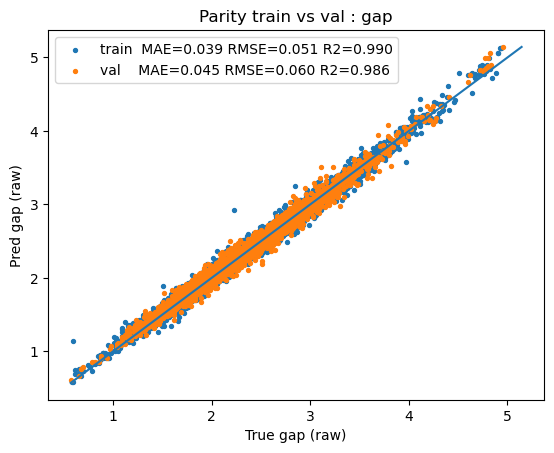

In [47]:
pred_tr, true_tr, smi_tr = predict_on_loader(model, train_loader, device, desc="predict(train)")
pred_va, true_va, smi_va = predict_on_loader(model, val_loader,   device, desc="predict(val)")
pred_te, true_te, smi_te = predict_on_loader(model, test_loader,  device, desc="predict(test)")

task_name = target_cols[0]           # example: first target
task_idx = target_cols.index(task_name)

med, iqr = scalers[task_name]

plot_parity_train_val_1task(true_tr, pred_tr,
                            true_va, pred_va,
                            task_name,
                            task_idx,
                            title=f"Parity train vs val : {task_name}",
                            max_points=20000,
                            med=med, iqr=iqr)

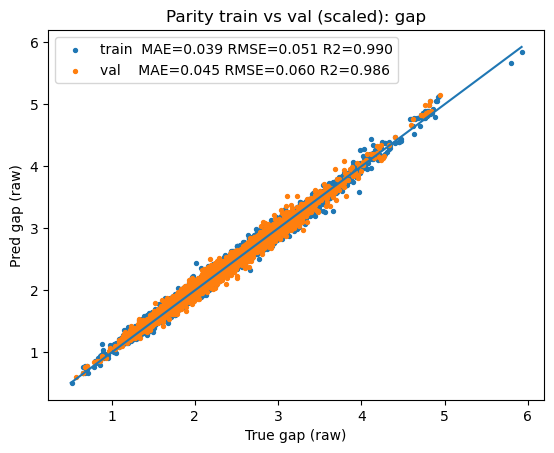

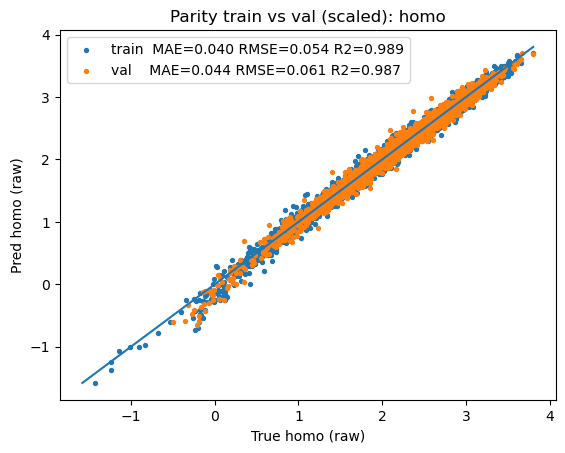

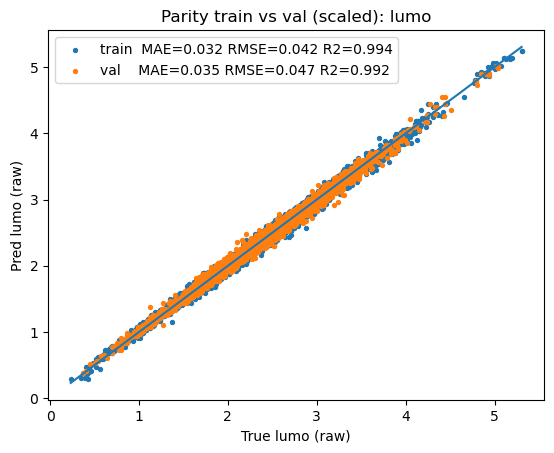

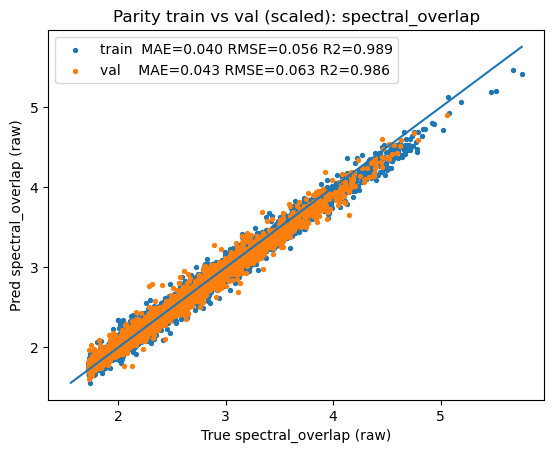

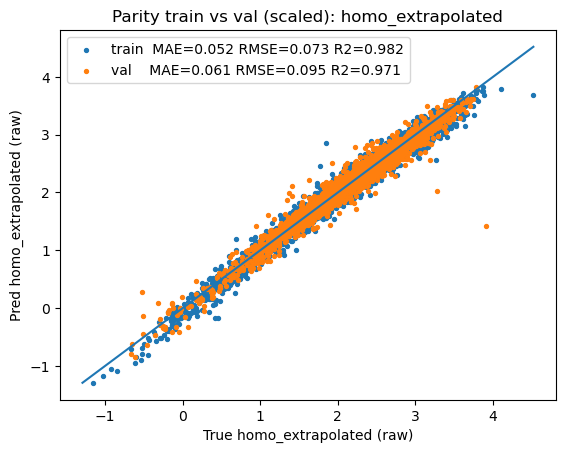

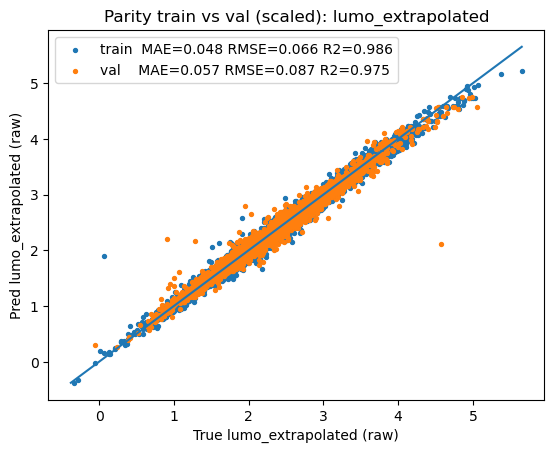

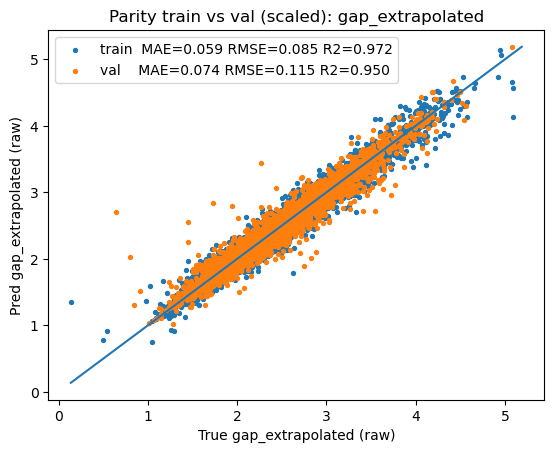

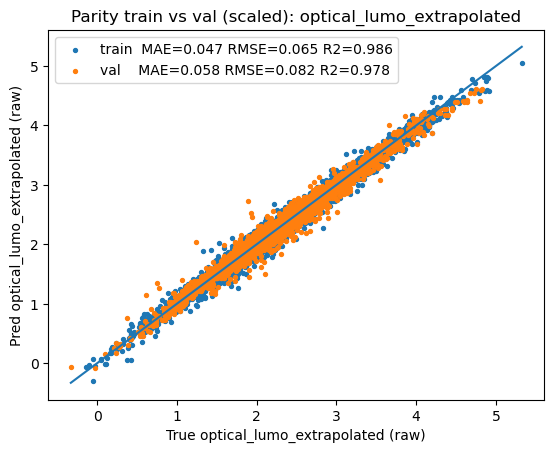

In [48]:
for task_name in target_cols:
    task_idx = target_cols.index(task_name)
    plot_parity_train_val_1task(true_tr, pred_tr, true_va, pred_va,
                                task_name, task_idx,
                                title=f"Parity train vs val (scaled): {task_name}",
                                max_points=20000,
                                med=med,
                                iqr=iqr)